In [1]:
# project: p13
# submitter: mmarkovic
# partner: None
# hours: 4

In [2]:
from math import radians, cos, sin, asin, sqrt
import requests
import json
import os
import pandas as pd
from pandas import DataFrame, Series

In [3]:
# Helper Functions

def download(filename, url):
    # We do not download again if the file already exists
    if os.path.exists(filename):
        return (str(filename) + " already exists!")

    r = requests.get(url)
    r.raise_for_status()
    data = r.text
    f = open(filename, "w", encoding="utf-8")
    f.write(data)
    f.close()

    return (str(filename) + " created!")


def qry(QUERRY):
    return pd.read_sql(QUERRY, conn)


In [4]:
download("countries.json", "https://raw.githubusercontent.com/msyamkumar/cs220-s21-projects/master/p13/countries.json")



'countries.json already exists!'

In [5]:
countries = pd.read_json('countries.json')

countries.head()

,area,birth-rate,coastline,continent,country,death-rate,gdp-per-capita,infant-mortality,literacy,net-migration,phones,population,region
0,756950,15.23,0.85,South America,Chile,5.81,9900,8.80,"96,2",0.00,"213,0",16134219,LATIN AMER. & CARIB
1,665,17.80,24.21,Asia,Bahrain,4.14,16900,17.27,"89,1",1.05,"281,3",698585,NEAR EAST
2,22966,28.84,1.68,North America,Belize,5.72,4900,25.69,"94,1",0.00,"115,7",287730,LATIN AMER. & CARIB
3,582650,39.72,0.09,Africa,Kenya,14.02,1000,61.47,"85,1",-0.10,"8,1",34707817,SUB-SAHARAN AFRICA
4,11854,33.05,3.12,Australia,Marshall Islands,4.78,1600,29.45,"93,7",-6.04,"91,2",60422,OCEANIA


In [6]:
import sqlite3
conn = sqlite3.connect('countries.db')
countries.to_sql("countries", conn, if_exists="replace", index=False)

# remember to do conn.close() at the end of your notebook


In [7]:
print(conn.total_changes)


174


In [8]:
#Q1: In our dataset, how many countries are in each continent?

countries_per_continent = qry("""
SELECT continent, COUNT(DISTINCT country) AS "number of countries"
FROM countries
GROUP BY continent
ORDER BY "number of countries" DESC, continent ASC
"""
)

countries_per_continent


,continent,number of countries
0,Africa,47
1,Europe,41
2,Asia,38
3,North America,24
4,Australia,12
5,South America,12


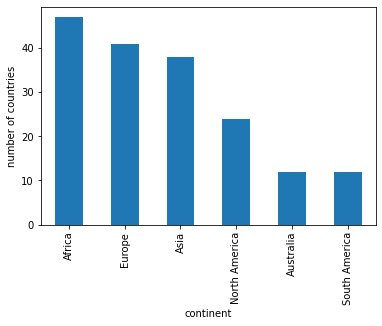

In [9]:
#Q2: How many countries are in each continent? (answer with a plot)

ax = countries_per_continent.plot.bar()
ax.set_ylabel("number of countries")
ax.set_xlabel("continent")
ax.set_xticklabels(countries_per_continent["continent"])
ax.get_legend().remove()


In [32]:
#Q3: What is the total population of each continent?

population_per_continent = qry("""
SELECT continent, (SUM(population)) / 1000000 AS "total population (million)"
FROM countries
GROUP BY continent
ORDER BY "total population (million)" DESC, continent ASC
"""
)

population_per_continent


,continent,total population (million)
0,Asia,3739
1,Africa,807
2,Europe,792
3,North America,515
4,South America,375
5,Australia,32


In [34]:
#This only takes population of first entry that has that specific continent.
#Example, Chile is first on the list.
#So, the population of S. America below is just the population of Chile, about 16 million.

#Changing population to SUM(population) gives you the full population of each continent then.

#GROUP BY is what groups all the rows then into the continents.
#Without GROUP BY, we would get every continent and population entry for each entry in the dataset (~174 countries entries total).

population_per_continent2 = qry("""
SELECT continent, population
FROM countries
GROUP BY continent
"""
)

population_per_continent2

,continent,population
0,Africa,34707817
1,Asia,698585
2,Australia,60422
3,Europe,40397842
4,North America,287730
5,South America,16134219


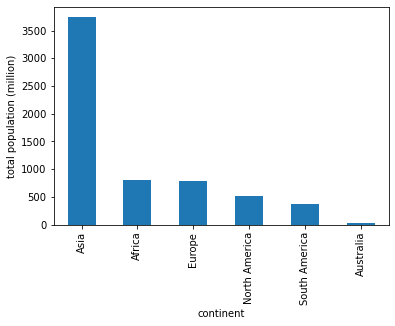

In [12]:
#Q4: What is the total population of each continent? (answer with a plot)

ax = population_per_continent.plot.bar()
ax.set_ylabel("total population (million)")
ax.set_xlabel("continent")
ax.set_xticklabels(population_per_continent["continent"])
ax.get_legend().remove()


In [47]:
#Q5: What is the population of each country in South America?

population_per_country_SA = qry("""
SELECT country, population
FROM countries
WHERE continent == "South America"
GROUP BY country
ORDER BY population DESC, country ASC
"""
)

population_per_country_SA


,country,population
0,Brazil,188078227
1,Colombia,43593035
2,Argentina,39921833
3,Peru,28302603
4,Venezuela,25730435
5,Chile,16134219
6,Ecuador,13547510
7,Bolivia,8989046
8,Paraguay,6506464
9,Uruguay,3431932


In [14]:
#Q6: What are the top 10 countries that have the largest real GDP?

gdp_per_country_limit = qry("""
SELECT country, (population * `gdp-per-capita`) / 1000000000 AS "Real GDP (billion)"
FROM countries
GROUP BY country
ORDER BY "Real GDP (billion)" DESC, country ASC
LIMIT 10
"""
)

gdp_per_country_limit


,country,Real GDP (billion)
0,United States,11281
1,China,6569
2,Japan,3594
3,India,3176
4,Germany,2274
5,France,1680
6,United Kingdom,1678
7,Italy,1552
8,Brazil,1429
9,Russia,1271


Text(0.5, 0, 'country')

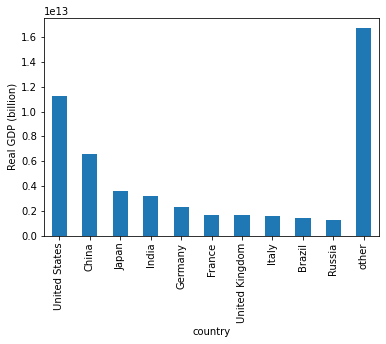

In [15]:
#Q7: What are the top 10 countries that have the largest real GDP? (answer with a plot)

gdp_per_country = qry("""
SELECT country, population * `gdp-per-capita` AS "Real GDP (billion)"
FROM countries
GROUP BY country
ORDER BY "Real GDP (billion)" DESC, country ASC
"""
)

gdp_per_country = gdp_per_country.set_index("country")


s_gdp_per_country = gdp_per_country["Real GDP (billion)"].iloc[:10]
s_gdp_per_country["other"] = gdp_per_country["Real GDP (billion)"].iloc[10:].sum()



ax = s_gdp_per_country.plot.bar()
ax.set_ylabel("Real GDP (billion)")
ax.set_xlabel("country")


<AxesSubplot:xlabel='gdp-per-capita', ylabel='literacy'>

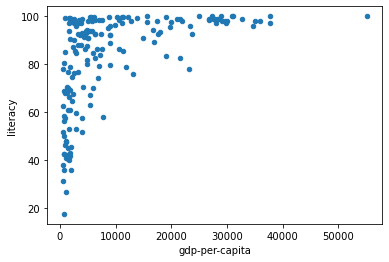

In [16]:
#Q8: What is the relationship between GDP per capita and literacy?

gdp_and_literacy = qry("""
SELECT `gdp-per-capita`, literacy
FROM countries
"""
)



#gdp_and_literacy = gdp_and_literacy.astype({'literacy':'float'})

#gdp_and_literacy.apply(lambda x: x.str.replace(',', '').astype(float), axis=1)

gdp_and_literacy = gdp_and_literacy.replace({',':'.'},regex=True).apply(pd.to_numeric,1)

gdp_and_literacy

gdp_and_literacy.plot.scatter(x='gdp-per-capita', y='literacy')


<AxesSubplot:xlabel='gdp-per-capita', ylabel='phones'>

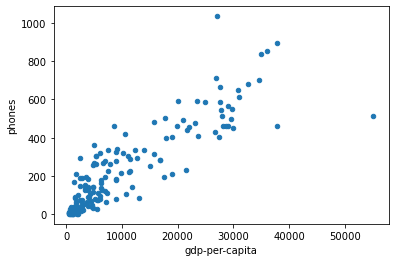

In [17]:
#Q9: What is the relationship between GDP per capita and phones?

gdp_and_phones = qry("""
SELECT `gdp-per-capita`, phones
FROM countries
"""
)

gdp_and_phones = gdp_and_phones.replace({',':'.'},regex=True).apply(pd.to_numeric,1)

gdp_and_phones

gdp_and_phones.plot.scatter(x='gdp-per-capita', y='phones')


In [18]:
#Q10: What is the correlation between GDP per capita and phones?

gdp_and_phones.corr()




,gdp-per-capita,phones
gdp-per-capita,1.000000,0.878695
phones,0.878695,1.000000


<AxesSubplot:xlabel='gdp-per-capita', ylabel='birth-rate'>

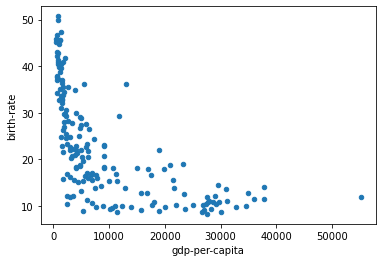

In [19]:
#Q11: What is the relationship between GDP per capita and birth rates?

gdp_and_birthrates = qry("""
SELECT `gdp-per-capita`, `birth-rate`
FROM countries
"""
)

gdp_and_birthrates

gdp_and_birthrates.plot.scatter(x='gdp-per-capita', y='birth-rate')


<AxesSubplot:xlabel='gdp-per-capita', ylabel='inverse-birth-rate'>

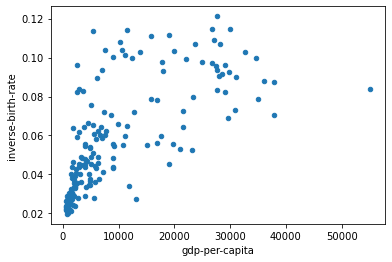

In [20]:
#Q12: What is the relationship between GDP per capita and inverse of birth rates?


gdp_and_inverse_birthrates = qry("""
SELECT `gdp-per-capita`, `birth-rate`
FROM countries
"""
)


gdp_and_inverse_birthrates = gdp_and_inverse_birthrates.rename(columns={'birth-rate': 'inverse-birth-rate'})

gdp_and_inverse_birthrates['inverse-birth-rate'] = gdp_and_inverse_birthrates['inverse-birth-rate'].apply(lambda x: 1/x)

gdp_and_inverse_birthrates

gdp_and_inverse_birthrates.plot.scatter(x='gdp-per-capita', y='inverse-birth-rate')


<AxesSubplot:xlabel='gdp-per-capita', ylabel='inverse-birth-rate'>

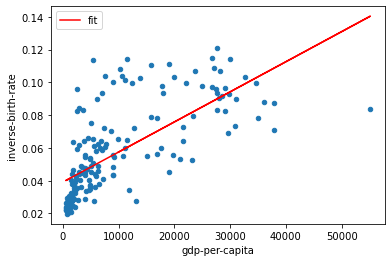

In [21]:
#Q13: fit a y = m * x + n line to the scatter plot in question 12 using the least-squares method; what are the coefficients m and n?

import numpy as np

gdp_and_inverse_birthrates = DataFrame({
    "gdp-per-capita": gdp_and_inverse_birthrates['gdp-per-capita'],
    "inverse-birth-rate": gdp_and_inverse_birthrates['inverse-birth-rate']
})

gdp_and_inverse_birthrates["1"] = 1

res = np.linalg.lstsq(gdp_and_inverse_birthrates[["gdp-per-capita", "1"]], gdp_and_inverse_birthrates["inverse-birth-rate"], rcond=None)

# res is a tuple: (COEFFICIENTS, VALUE, VALUE, VALUE)
coefficients = res[0] # coefficients is (m,n:
m = coefficients[0] # slope
n = coefficients[1] # intercept
ax = gdp_and_inverse_birthrates.plot.scatter(x='gdp-per-capita', y='inverse-birth-rate')

gdp_and_inverse_birthrates["fit"] = gdp_and_inverse_birthrates["gdp-per-capita"] * m + n
gdp_and_inverse_birthrates.plot.line(x='gdp-per-capita', y='fit', c='red', ax=ax)

In [22]:
#Q14: When gdp-per-capita = 30000, what is the expected value for birth rate according to the regression model from Q13?



In [23]:
#Q15: plot the regression line to the scatter plot




In [19]:
#Q16: What are the top 15 countries that have the largest gap between birth rate and death rate?

largest_gap_birth_death_rate = qry("""
SELECT country, (`birth-rate`-`death-rate`) AS "birth-death rate difference"
FROM countries
ORDER BY "birth-death rate difference" DESC
LIMIT 15
""")


largest_gap_birth_death_rate

,country,birth-death rate difference
0,Uganda,35.11
1,Yemen,34.59
2,Mali,32.93
3,Oman,32.43
4,Madagascar,30.30
5,Burkina Faso,30.02
6,Niger,29.82
7,Chad,29.35
8,Mauritania,28.83
9,Burundi,28.76


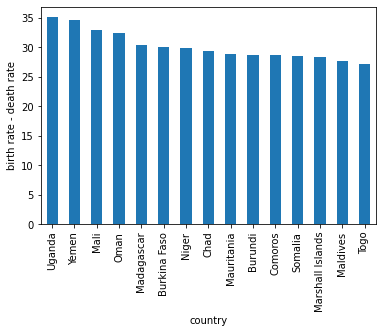

In [21]:
#Q17: What are the top 15 countries that have the largest gap between birth rate and death rate? (answer with a plot)

ax = largest_gap_birth_death_rate.plot.bar()
ax.set_ylabel("birth rate - death rate")
ax.set_xlabel("country")
ax.set_xticklabels(largest_gap_birth_death_rate["country"])
ax.get_legend().remove()



In [24]:
print(conn.total_changes)


174


In [25]:
#conn.close()